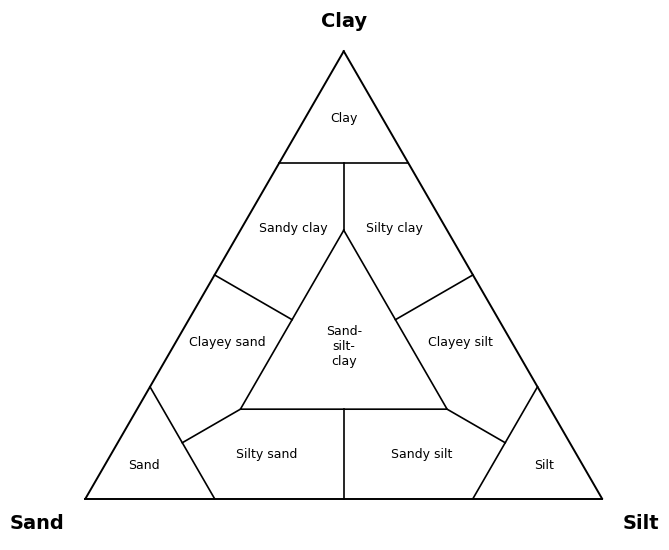

In [23]:
import numpy as np
import matplotlib.pyplot as plt

SQRT3 = np.sqrt(3.0)

def ternary_to_xy(sand, silt, clay):
    sand = np.asarray(sand, dtype=float)
    silt = np.asarray(silt, dtype=float)
    clay = np.asarray(clay, dtype=float)

    total = sand + silt + clay
    if not np.allclose(total, 100.0):
        raise ValueError("Each point must sum to 100.")

    x = (silt + 0.5 * clay) / 100.0
    y = (SQRT3 / 2.0) * clay / 100.0
    return x, y


def draw_segment(ax, p1, p2, **kwargs):
    x1, y1 = ternary_to_xy(*p1)
    x2, y2 = ternary_to_xy(*p2)
    ax.plot([x1, x2], [y1, y2], **kwargs)


def draw_polygon(ax, points, **kwargs):
    pts = np.asarray(points, dtype=float)
    x, y = ternary_to_xy(pts[:, 0], pts[:, 1], pts[:, 2])
    ax.plot(np.r_[x, x[0]], np.r_[y, y[0]], **kwargs)


def add_text_ternary(ax, sand, silt, clay, text, fs=9):
    x, y = ternary_to_xy(sand, silt, clay)
    ax.text(x, y, text, ha="center", va="center", fontsize=fs)


def plot_simple_shepard(figsize=(8, 7)):
    fig, ax = plt.subplots(figsize=figsize)

    # Outer triangle
    draw_segment(ax, (100, 0, 0), (0, 100, 0), color="k", lw=1.4)
    draw_segment(ax, (100, 0, 0), (0, 0, 100), color="k", lw=1.4)
    draw_segment(ax, (0, 100, 0), (0, 0, 100), color="k", lw=1.4)

    # Primary boundaries
    draw_segment(ax, (75, 0, 25), (75, 25, 0), color="k", lw=1.2)
    draw_segment(ax, (25, 75, 0), (0, 75, 25), color="k", lw=1.2)
    draw_segment(ax, (0, 25, 75), (25, 0, 75), color="k", lw=1.2)

    # Inner triangle
    inner_triangle = [(20,20,60),(60,20,20),(20,60,20)]
    draw_polygon(ax, inner_triangle, color="k", lw=1.2)

    # Connecting segments
    draw_segment(ax, (75,12.5,12.5), (60,20,20), color="k", lw=1.2)
    draw_segment(ax, (12.5,75,12.5), (20,60,20), color="k", lw=1.2)
    draw_segment(ax, (12.5,12.5,75), (20,20,60), color="k", lw=1.2)

    draw_segment(ax, (50,0,50), (40,20,40), color="k", lw=1.2)
    draw_segment(ax, (50,50,0), (40,40,20), color="k", lw=1.2)
    draw_segment(ax, (0,50,50), (20,40,40), color="k", lw=1.2)

    # --------------------------------------------------------
    # CLASS LABELS (small font)
    # --------------------------------------------------------

    # Corners
    add_text_ternary(ax, 85, 7.5, 7.5, "Sand")
    add_text_ternary(ax, 7.5, 85, 7.5, "Silt")
    add_text_ternary(ax, 7.5, 7.5, 85, "Clay")

    # Lower fields
    add_text_ternary(ax, 60, 30, 10, "Silty sand")
    add_text_ternary(ax, 30, 60, 10, "Sandy silt")

    # Side clayey fields
    add_text_ternary(ax, 55, 10, 35, "Clayey sand")
    add_text_ternary(ax, 10, 55, 35, "Clayey silt")

    # Upper mixed clay fields
    add_text_ternary(ax, 29.5, 10, 60.5, "Sandy clay")
    add_text_ternary(ax, 10, 29.5, 60.5, "Silty clay")

    # Center
    add_text_ternary(ax, 33, 33, 34, "Sand-\nsilt-\nclay")

    # --------------------------------------------------------
    # Axis labels outside
    # --------------------------------------------------------
    ax.text(-0.04, -0.03, "Sand", ha="right", va="top", fontsize=14, fontweight="bold")
    ax.text(1.04, -0.03, "Silt", ha="left", va="top", fontsize=14, fontweight="bold")
    ax.text(0.50, SQRT3/2 + 0.04, "Clay", ha="center", va="bottom", fontsize=14, fontweight="bold")

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_aspect("equal")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.08, SQRT3/2 + 0.08)
    ax.axis("off")

    return fig, ax


# Run
fig, ax = plot_simple_shepard(figsize=(8,8))
plt.show()

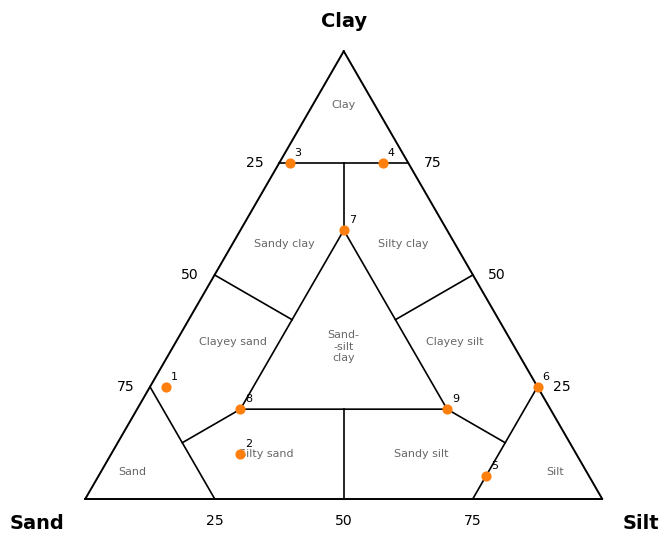

In [38]:
# Plot sand/silt/clay on a Shepard diagram (ternary plot)
# Chris Sherwood + ChatGPT 5.2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

SQRT3 = np.sqrt(3.0)

# ============================================================
# TERNARY TRANSFORM
# ============================================================
def ternary_to_xy(sand, silt, clay):
    sand = np.asarray(sand, dtype=float)
    silt = np.asarray(silt, dtype=float)
    clay = np.asarray(clay, dtype=float)

    total = sand + silt + clay
    if not np.allclose(total, 100.0):
        raise ValueError("Each point must sum to 100.")

    x = (silt + 0.5 * clay) / 100.0
    y = (SQRT3 / 2.0) * clay / 100.0
    return x, y


def draw_segment(ax, p1, p2, **kwargs):
    x1, y1 = ternary_to_xy(*p1)
    x2, y2 = ternary_to_xy(*p2)
    ax.plot([x1, x2], [y1, y2], **kwargs)


def draw_polygon(ax, points, **kwargs):
    pts = np.asarray(points, dtype=float)
    x, y = ternary_to_xy(pts[:, 0], pts[:, 1], pts[:, 2])
    ax.plot(np.r_[x, x[0]], np.r_[y, y[0]], **kwargs)


def add_text_ternary(ax, sand, silt, clay, text, fs=8, color="0.4"):
    x, y = ternary_to_xy(sand, silt, clay)
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=color)


# ============================================================
# READ CSV
# ============================================================
def read_shepard_csv(csv_file="shepard_test.csv", atol=1e-6):
    csv_file = Path(csv_file)

    if not csv_file.exists():
        warnings.warn(f"{csv_file} not found. Plotting diagram only.")
        return None

    df = pd.read_csv(csv_file)

    required = ["sand", "silt", "clay"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"CSV file is missing required columns: {missing}")

    sums = df[required].sum(axis=1)
    bad = ~np.isclose(sums.values, 100.0, atol=atol)

    if bad.any():
        bad_rows = np.where(bad)[0]
        msg = [f"Rows in {csv_file.name} do not sum to 100%:"]
        for i in bad_rows:
            msg.append(
                f"  row {i}: sand={df.loc[i,'sand']}, "
                f"silt={df.loc[i,'silt']}, clay={df.loc[i,'clay']}, "
                f"sum={sums.iloc[i]}"
            )
        warnings.warn("\n".join(msg))

    return df


# ============================================================
# MAIN PLOT
# ============================================================
def plot_simple_shepard(
    df_points=None,
    figsize=(8, 8),
    marker_size=40,
    label_points=False,
    label_fs=8,
    label_offset=(0.01, 0.01),
):
    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------------
    # OUTER TRIANGLE
    # --------------------------------------------------------
    draw_segment(ax, (100, 0, 0), (0, 100, 0), color="k", lw=1.4)
    draw_segment(ax, (100, 0, 0), (0, 0, 100), color="k", lw=1.4)
    draw_segment(ax, (0, 100, 0), (0, 0, 100), color="k", lw=1.4)

    # --------------------------------------------------------
    # PRIMARY BOUNDARIES
    # --------------------------------------------------------
    draw_segment(ax, (75, 0, 25), (75, 25, 0), color="k", lw=1.2)
    draw_segment(ax, (25, 75, 0), (0, 75, 25), color="k", lw=1.2)
    draw_segment(ax, (0, 25, 75), (25, 0, 75), color="k", lw=1.2)

    # --------------------------------------------------------
    # INNER TRIANGLE
    # --------------------------------------------------------
    inner_triangle = [(20, 20, 60), (60, 20, 20), (20, 60, 20)]
    draw_polygon(ax, inner_triangle, color="k", lw=1.2)

    # --------------------------------------------------------
    # CONNECTING SEGMENTS
    # --------------------------------------------------------
    draw_segment(ax, (75, 12.5, 12.5), (60, 20, 20), color="k", lw=1.2)
    draw_segment(ax, (12.5, 75, 12.5), (20, 60, 20), color="k", lw=1.2)
    draw_segment(ax, (12.5, 12.5, 75), (20, 20, 60), color="k", lw=1.2)

    # corrected midpoint connections
    draw_segment(ax, (50, 0, 50), (40, 20, 40), color="k", lw=1.2)
    draw_segment(ax, (50, 50, 0), (40, 40, 20), color="k", lw=1.2)
    draw_segment(ax, (0, 50, 50), (20, 40, 40), color="k", lw=1.2)

    # --------------------------------------------------------
    # CLASS LABELS (light gray)
    # --------------------------------------------------------
    add_text_ternary(ax, 88, 6, 6, "Sand")
    add_text_ternary(ax, 6, 88, 6, "Silt")
    add_text_ternary(ax, 6, 6, 88, "Clay")

    add_text_ternary(ax, 60, 30, 10, "Silty sand")
    add_text_ternary(ax, 30, 60, 10, "Sandy silt")

    add_text_ternary(ax, 54, 11, 35, "Clayey sand")
    add_text_ternary(ax, 11, 54, 35, "Clayey silt")

    add_text_ternary(ax, 33, 10, 57, "Sandy clay")
    add_text_ternary(ax, 10, 33, 57, "Silty clay")

    add_text_ternary(ax, 33, 33, 34, "Sand-\n-silt\nclay")

    # --------------------------------------------------------
    # PLOT POINTS
    # --------------------------------------------------------
    if df_points is not None:
        x, y = ternary_to_xy(
            df_points["sand"].values,
            df_points["silt"].values,
            df_points["clay"].values,
        )

        ax.scatter(x, y, s=marker_size, color="tab:orange", zorder=5)

        if label_points:
            if "id" not in df_points.columns:
                raise ValueError("CSV must contain 'id' column for labeling.")

            dx, dy = label_offset
            for xi, yi, label in zip(x, y, df_points["id"]):
                ax.text(
                    xi + dx,
                    yi + dy,
                    str(label),
                    fontsize=label_fs,
                    ha="left",
                    va="bottom",
                    color="k",
                )

    # --------------------------------------------------------
    # AXIS LABELS (outside)
    # --------------------------------------------------------
    ax.text(-0.04, -0.03, "Sand", ha="right", va="top",
            fontsize=14, fontweight="bold")
    ax.text(1.04, -0.03, "Silt", ha="left", va="top",
            fontsize=14, fontweight="bold")
    ax.text(0.50, SQRT3 / 2 + 0.04, "Clay", ha="center", va="bottom",
            fontsize=14, fontweight="bold")

    # --------------------------------------------------------
    # TICKS
    # --------------------------------------------------------
    for silt in [25, 50, 75]:
        sand = 100 - silt
        x, y = ternary_to_xy(sand, silt, 0)
        ax.text(x, y - 0.03, f"{silt}", ha="center", va="top", fontsize=10)

    for clay in [25, 50, 75]:
        sand = 100 - clay
        x, y = ternary_to_xy(sand, 0, clay)
        ax.text(x - 0.03, y, f"{sand}", ha="right", va="center", fontsize=10)

    for clay in [25, 50, 75]:
        x, y = ternary_to_xy(0, 100 - clay, clay)
        ax.text(x + 0.03, y, f"{clay}", ha="left", va="center", fontsize=10)

    # --------------------------------------------------------
    # FINAL FORMATTING
    # --------------------------------------------------------
    ax.set_aspect("equal")
    ax.set_xlim(-0.10, 1.10)
    ax.set_ylim(-0.08, SQRT3 / 2 + 0.08)
    ax.axis("off")

    return fig, ax


# ============================================================
# RUN
# ============================================================
df_points = read_shepherd_csv("shepard_test.csv")

fig, ax = plot_simple_shepard(
    df_points=df_points,
    label_points=True,   # <-- toggle labels here
)
plt.show()